# 00 — Setup e verificação do ambiente

Este é o **primeiro notebook** a rodar. Ele garante que o ambiente está funcional **antes** de qualquer trabalho de dados ou treino.

Verificamos:
1. Versão do TensorFlow e do tensorflow-datasets
2. Detecção da GPU (via WSL2 + driver NVIDIA do Windows)
3. Configuração de *memory growth* (evita que o TF tome toda a VRAM de uma vez)
4. Carregamento de uma amostra do EuroSAT all-bands

> **Se algo falhar aqui, pare e conserte antes de seguir.** Consulte `docs/gpu_setup_guide.md`.

In [2]:
import sys, os
# Garante que o pacote `src` (na raiz do projeto) seja importável a partir de notebooks/.
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

from src import config
from src import visualization as viz

print('TensorFlow      :', tf.__version__)
print('tfds            :', tfds.__version__)
print('NumPy           :', np.__version__)

TensorFlow      : 2.21.0
tfds            : 4.9.10
NumPy           : 2.4.6


## 1. Detecção da GPU

O TF deve listar pelo menos um dispositivo `GPU`. Caso contrário, revise o guia de setup (driver NVIDIA no Windows + `tensorflow[and-cuda]` no venv).

In [3]:
gpus = tf.config.list_physical_devices('GPU')
print('GPUs detectadas:', gpus)

# Memory growth: aloca VRAM sob demanda em vez de tomar tudo de cara.
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

assert gpus, 'Nenhuma GPU detectada — veja docs/gpu_setup_guide.md antes de continuar.'
print('\nMemory growth ativado. Ambiente de GPU OK.')

GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Memory growth ativado. Ambiente de GPU OK.


In [4]:
# Teste rápido: uma multiplicação de matrizes na GPU.
with tf.device('/GPU:0'):
    a = tf.random.normal([2000, 2000])
    b = tf.matmul(a, a)
print('Multiplicação na GPU OK — shape do resultado:', b.shape)

Multiplicação na GPU OK — shape do resultado: (2000, 2000)


I0000 00:00:1780156327.227929    3692 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6


## 2. Mixed precision

Em GPUs modernas (Turing+), usar `float16` nas operações intermediárias acelera o treino ~2× e reduz uso de VRAM, mantendo a saída em `float32` por estabilidade. Definimos a política globalmente; os modelos em `src/models.py` já forçam a última camada para `float32`.

In [5]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print('Política de precisão:', mixed_precision.global_policy())

Política de precisão: <DTypePolicy "mixed_float16">


## 3. Carregar uma amostra do EuroSAT

Carregamos **uma** imagem do dataset all-bands para confirmar que o cache do tfds está preparado e que o tensor tem o formato esperado `(64, 64, 13)`.

> Se o dataset ainda não estiver baixado, rode antes (uma única vez): `python scripts/prepare_dataset.py` no venv. O download oficial está com HTTP 403, então usamos um mirror — ver o script.

In [6]:
ds = tfds.load(config.DATASET_NAME, split='train', shuffle_files=False)
example = next(iter(ds.take(1)))
image = example[config.IMAGE_KEY].numpy()
label = int(example[config.LABEL_KEY])

print('Shape da imagem :', image.shape, image.dtype)
print('Faixa de valores:', image.min(), '..', image.max())
print('Classe          :', config.CLASS_NAMES[label])

I0000 00:00:1780156327.995382    3916 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Shape da imagem : (64, 64, 13) float32
Faixa de valores: 6.0 .. 4812.0
Classe          : River


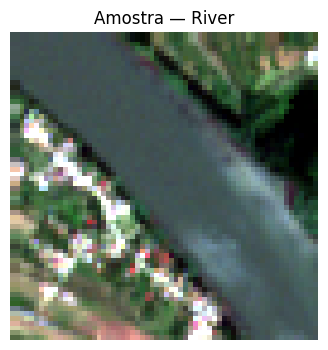

In [7]:
# Composição RGB visível (B4,B3,B2) com realce de contraste só para exibição.
plt.figure(figsize=(4, 4))
plt.imshow(viz.rgb_composite(image))
plt.title(f'Amostra — {config.CLASS_NAMES[label]}')
plt.axis('off')
plt.show()

## Conclusão

Se todas as células acima rodaram sem erro — GPU detectada, multiplicação na GPU OK, e a amostra do EuroSAT carregou com shape `(64, 64, 13)` — o ambiente está pronto.

**Próximo passo:** `01_data_exploration.ipynb`.